# MacroHack Pipeline Demo (code4)

This notebook runs `code4.py` (the main non-CV pipeline) and then checks generated artifacts.


In [41]:
from pathlib import Path
import runpy

ROOT = Path.cwd()
SCRIPT = ROOT / 'pipeline.py'
OUTPUT_DIR = ROOT / 'outputs'
SUBMISSION = ROOT / 'Problem_1_yield_curve_predict.xlsx'

print('Root      :', ROOT)
print('Script    :', SCRIPT)
print('Outputs   :', OUTPUT_DIR)
print('Submission:', SUBMISSION)


Root      : /Users/kseniasemenova/Downloads/macrohack-main 5
Script    : /Users/kseniasemenova/Downloads/macrohack-main 5/pipeline.py
Outputs   : /Users/kseniasemenova/Downloads/macrohack-main 5/outputs
Submission: /Users/kseniasemenova/Downloads/macrohack-main 5/Problem_1_yield_curve_predict.xlsx


In [42]:
def show_inputs() -> None:
    required = [
        ROOT / 'data' / 'ns_results' / 'betas_0_7308.csv',
        ROOT / 'data' / 'inputs' / 'yield_curve.xlsx',
        ROOT / 'data' / 'inputs' / 'macro_updated.xlsx',
        ROOT / 'data' / 'inputs' / 'Problem_1_IV_train.xlsx',
    ]

    print('Input files:')
    for p in required:
        print(f' - {p} -> {p.exists()}')

show_inputs()


Input files:
 - /Users/kseniasemenova/Downloads/macrohack-main 5/data/ns_results/betas_0_7308.csv -> True
 - /Users/kseniasemenova/Downloads/macrohack-main 5/data/inputs/yield_curve.xlsx -> True
 - /Users/kseniasemenova/Downloads/macrohack-main 5/data/inputs/macro_updated.xlsx -> True
 - /Users/kseniasemenova/Downloads/macrohack-main 5/data/inputs/Problem_1_IV_train.xlsx -> True


Running code4.py ...
Loading data …
Extracting IV features …
  Aligned: 2019-03 → 2025-09  (79 months)

  Splits → train:67  val:6  trainval:73  test:6

  IV PCA  : 3 PCs [91.0%, 7.1%, 1.3%]
  Macro PCA: 3 PCs [46.3%, 23.3%, 12.0%]

── ARIMA grid-search (NS betas) ──
  beta0: (2, 1, 2)  val_MSE=82.67427
  beta1: (0, 1, 2)  val_MSE=79.01893
  beta2: (2, 1, 1)  val_MSE=30.86957

── Svensson lambda grid-search ──
  Train    λ₁*=0.30  λ₂*=4.00  RMSE=0.17487
  Trainval λ₁*=0.30  λ₂*=4.00  RMSE=0.17353

── Random Walk baseline ──
  RW RMSE = 3.49898  ← must beat this

§17  Tournament back-test …
  ARIMA_NS                          no-IV: 4.46790  ✗ (-27.7% vs RW)
  ARIMAX_NS_macro_pca_iv1           IV: 3.36694  ✓ (+3.8% vs RW)

  [F3] SV_ARIMA two-phase fit …
  [SV] λ₁*=0.30  λ₂*=4.00  train-RMSE=0.17487
  [SV] ARIMA order grid-search …
    sv_b0: (3, 0, 1)  val_MSE=332.54610
    sv_b1: (3, 1, 2)  val_MSE=136.39869
    sv_b2: (3, 1, 1)  val_MSE=112.66509
    sv_b3: (0, 1, 2)  val_MSE=2206.12

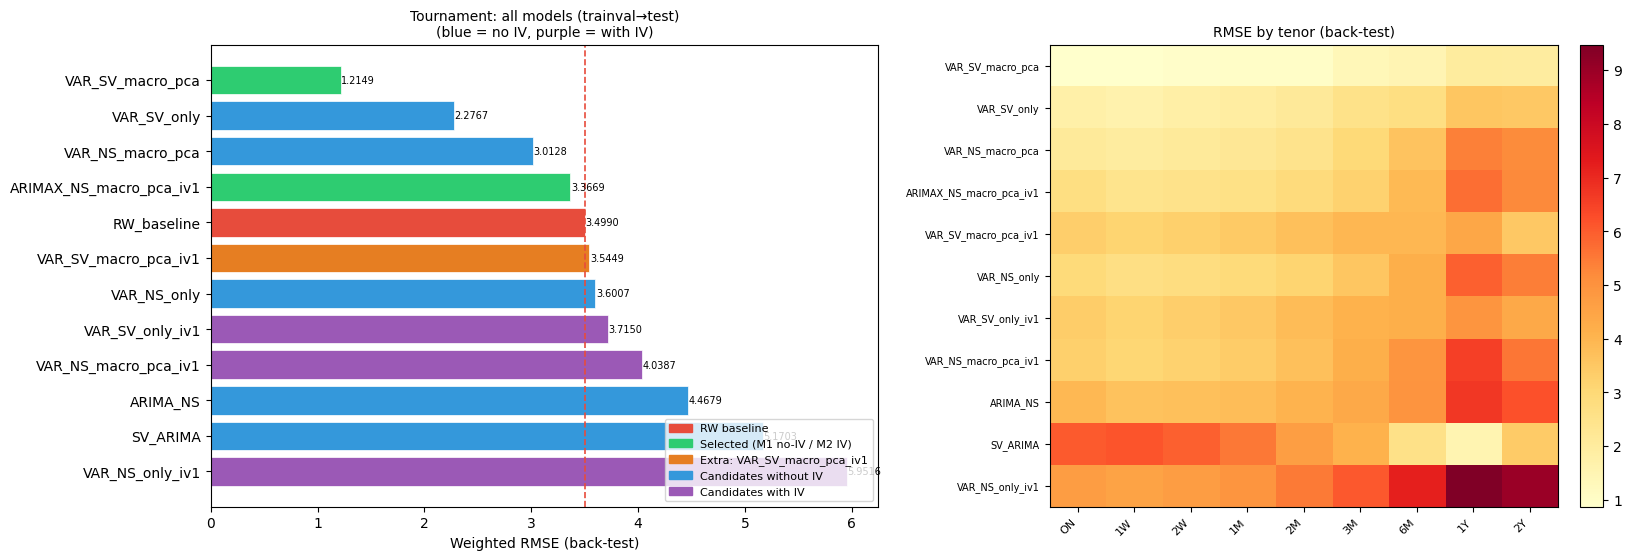

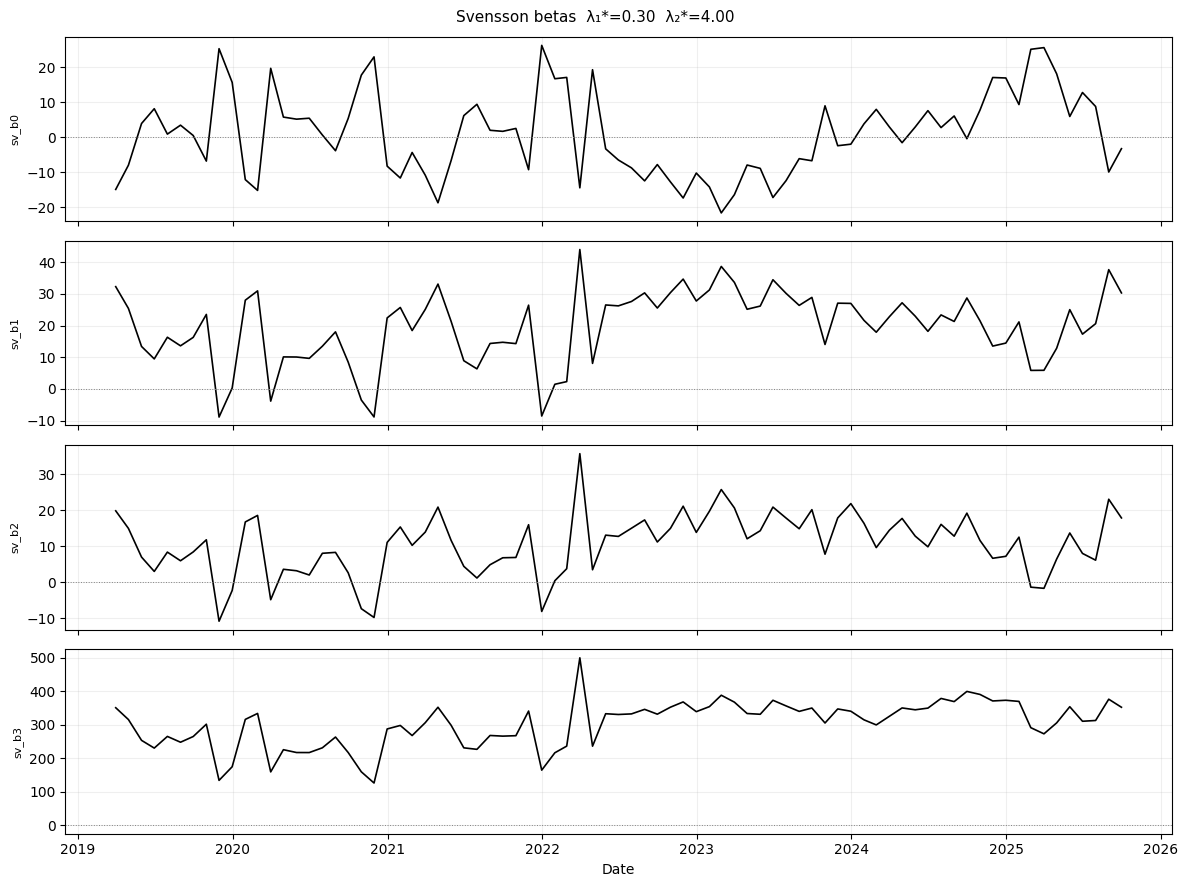

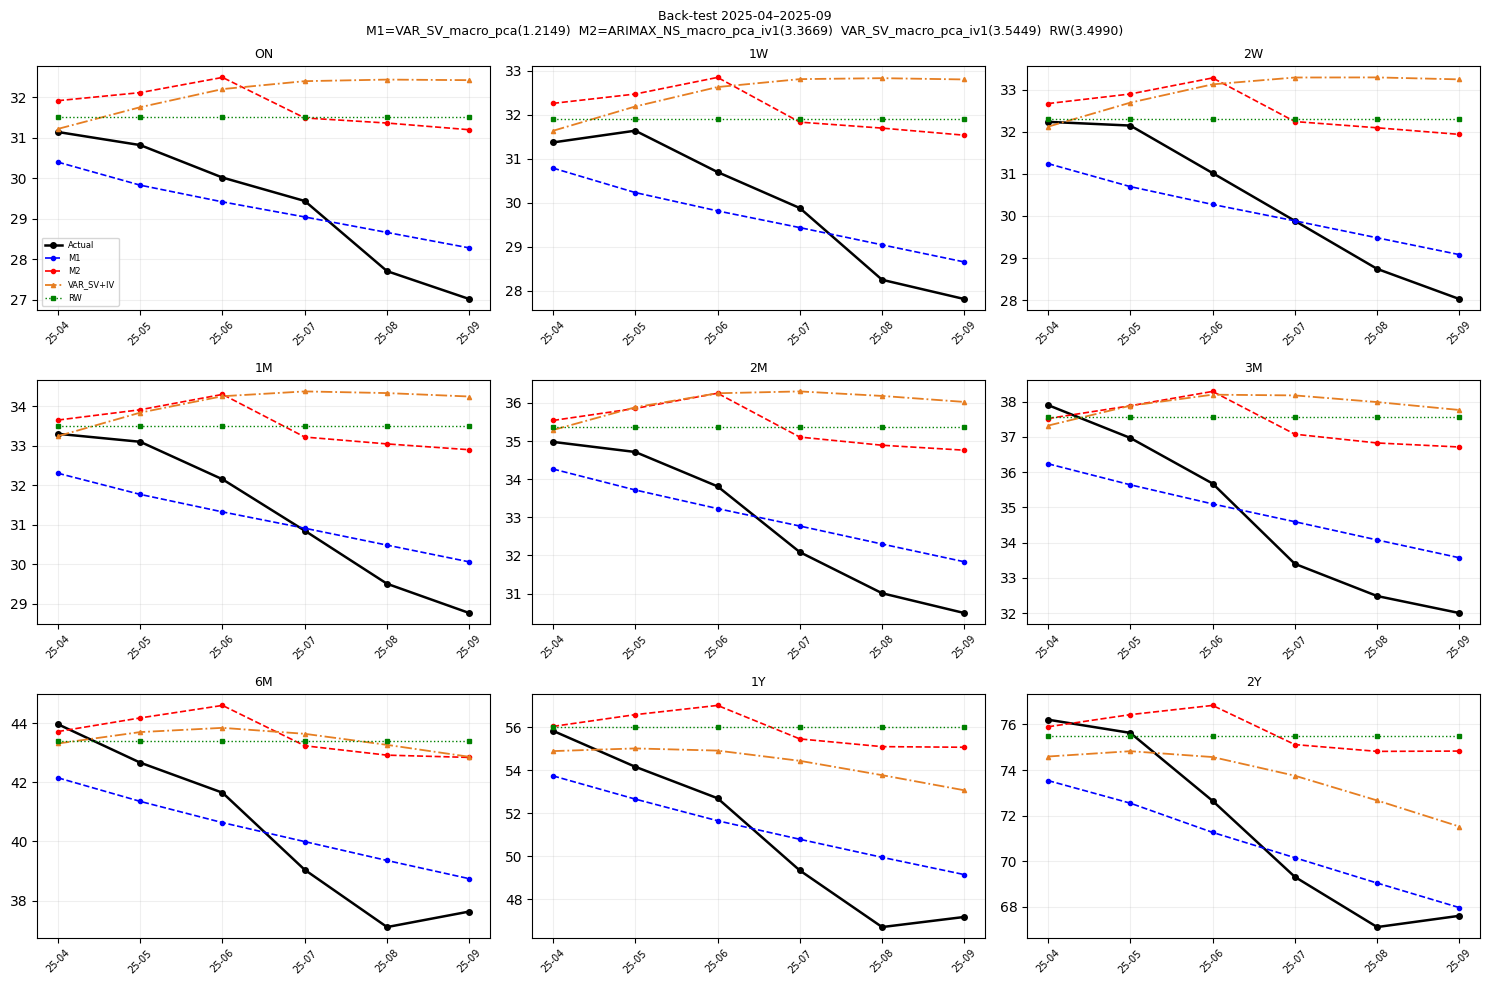

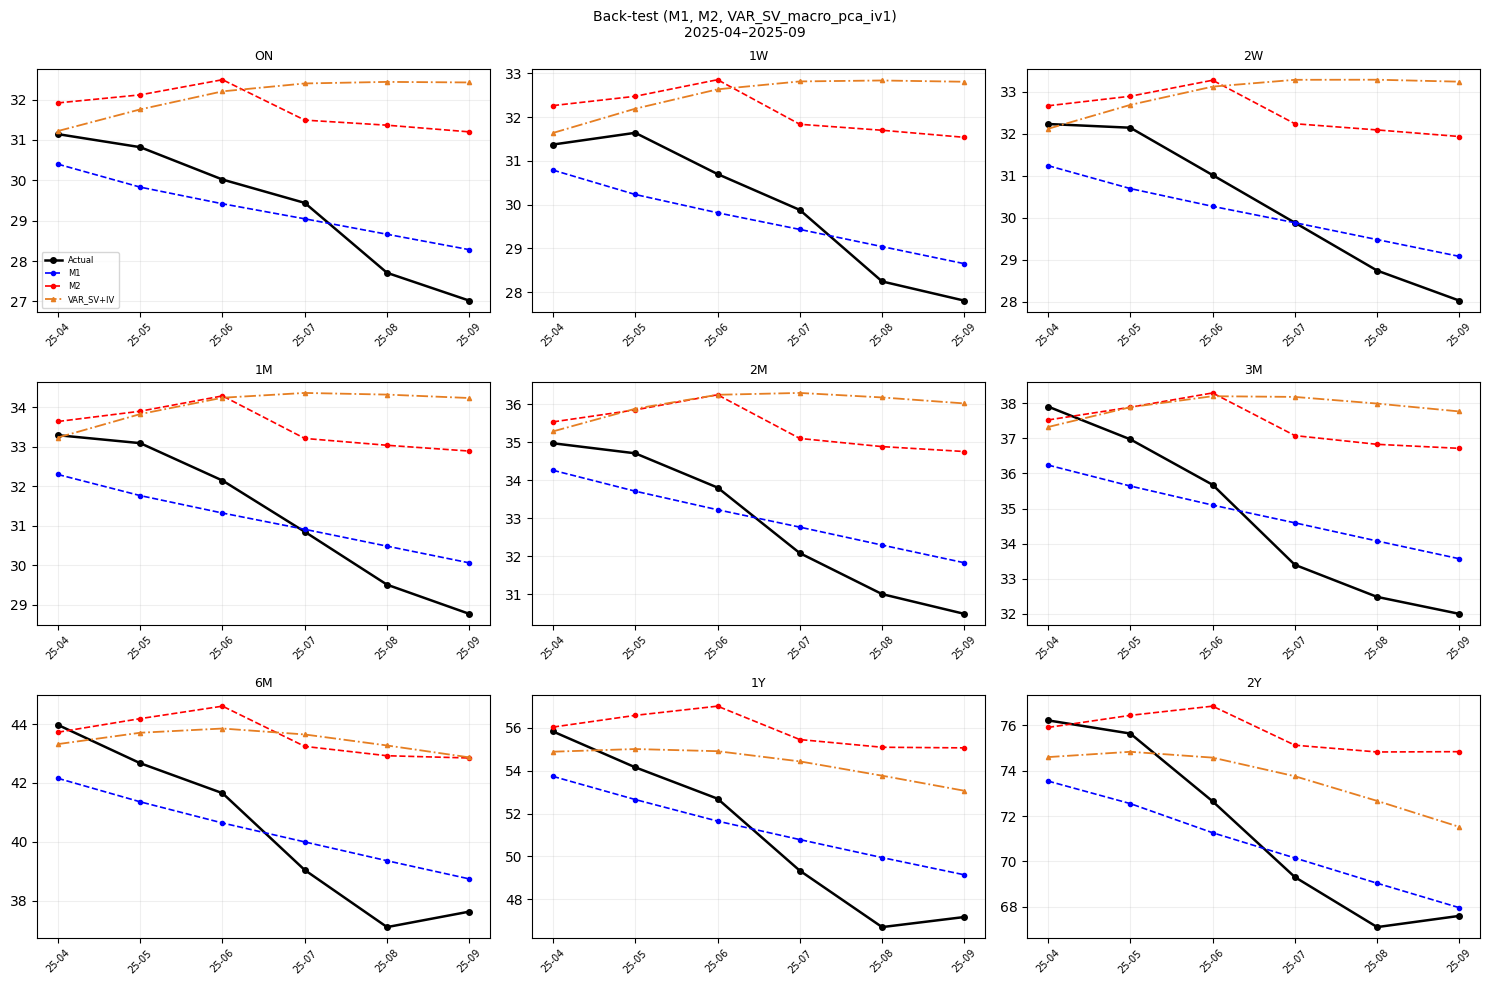

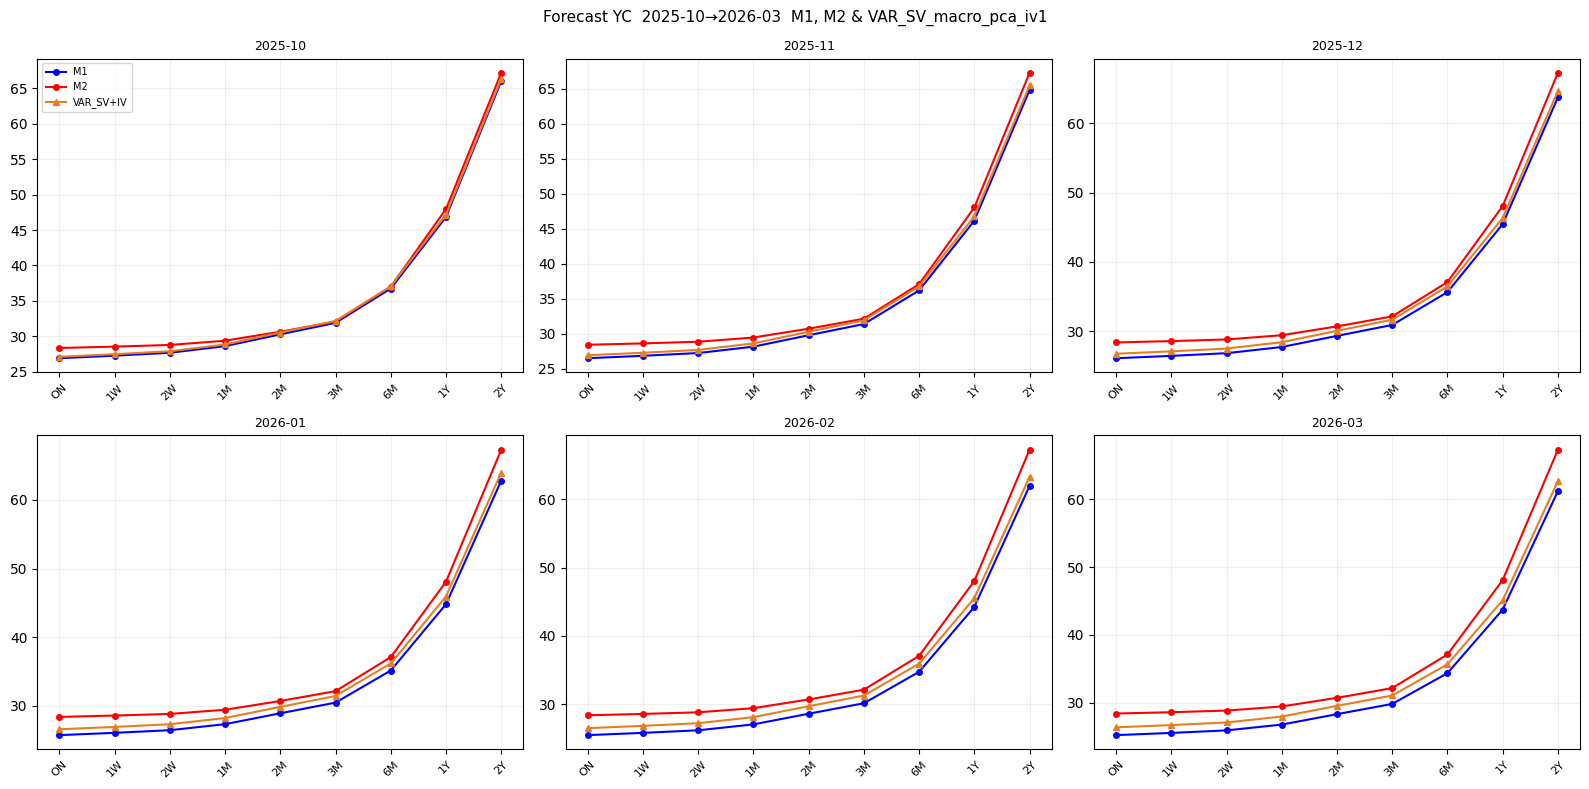


FINAL SUMMARY  (v3 — all bugs fixed)
  Sample  : 2019-03 → 2025-09  (79 months)
  Svensson: λ₁*=0.30  λ₂*=4.00  (train: λ₁*=0.30  λ₂*=4.00)
  IV PCA  : [88.7%, 8.5%, 2.1%]
  MacroPCA: [46.1%, 22.1%, 12.7%]

  Back-test (2025-04→2025-09):
    Random Walk  = 3.49898

  No-IV family (sorted) — sheet M1:
    VAR_SV_macro_pca                   = 1.21490  ✓ (+65.3% vs RW) ◀ SELECTED
    VAR_SV_only                        = 2.27666  ✓ (+34.9% vs RW)
    VAR_NS_macro_pca                   = 3.01282  ✓ (+13.9% vs RW)
    VAR_NS_only                        = 3.60066  ✗ (-2.9% vs RW)
    ARIMA_NS                           = 4.46790  ✗ (-27.7% vs RW)
    SV_ARIMA                           = 5.17031  ✗ (-47.8% vs RW)

  With-IV family (sorted) — sheet M2:
    ARIMAX_NS_macro_pca_iv1            = 3.36694  ✓ (+3.8% vs RW) ◀ SELECTED
    VAR_SV_macro_pca_iv1               = 3.54485  ✗ (-1.3% vs RW)
    VAR_SV_only_iv1                    = 3.71504  ✗ (-6.2% vs RW)
    VAR_NS_macro_pca_iv1             

{'__name__': '__main__',
 '__doc__': '\nmacrohack_all_fixed_v3.py\n=========================\nDIAGNOSIS → FIXES:\n  D1 → F1  SV lambda grid constrained: λ₁∈[0.3..2.5], λ₂∈[2.0..7.0], λ₂>λ₁+0.5\n  D2 → F2  VAR variable cap MAX_VAR_TOTAL_VARS=7; IV block uses only iv_pc1 (iv_n=1)\n  D3 → F3  SvenssonARIMAForecaster: two-phase fit + refit_arima_only()\n  D4 → F4  Remove all raw-macro VAR specs; keep pca-only\n  D5 → F5  New ARIMAX M2 (macro_pca+iv_pc1 as exog) + RW floor if no M2 beats RW\n       F6  SV beta stability: clip betas ±500 after OLS\n',
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': '/Users/kseniasemenova/Downloads/macrohack-main 5/pipeline.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is n

In [43]:
print('Running code4.py ...')
runpy.run_path(str(SCRIPT), run_name='__main__')


In [44]:
EXPECTED = [
    SUBMISSION,
    OUTPUT_DIR / 'tournament_rmse.png',
    OUTPUT_DIR / 'svensson_betas.png',
    OUTPUT_DIR / 'backtest_per_tenor.png',
    OUTPUT_DIR / 'final_yc_forecasts.png',
]

print('Checking generated files:')
for p in EXPECTED:
    print(f'{p}: {p.exists()}')


Checking generated files:
/Users/kseniasemenova/Downloads/macrohack-main 5/Problem_1_yield_curve_predict.xlsx: True
/Users/kseniasemenova/Downloads/macrohack-main 5/outputs/tournament_rmse.png: True
/Users/kseniasemenova/Downloads/macrohack-main 5/outputs/svensson_betas.png: True
/Users/kseniasemenova/Downloads/macrohack-main 5/outputs/backtest_per_tenor.png: True
/Users/kseniasemenova/Downloads/macrohack-main 5/outputs/final_yc_forecasts.png: True
